# ```Observe Retrieval Operations and Drift```

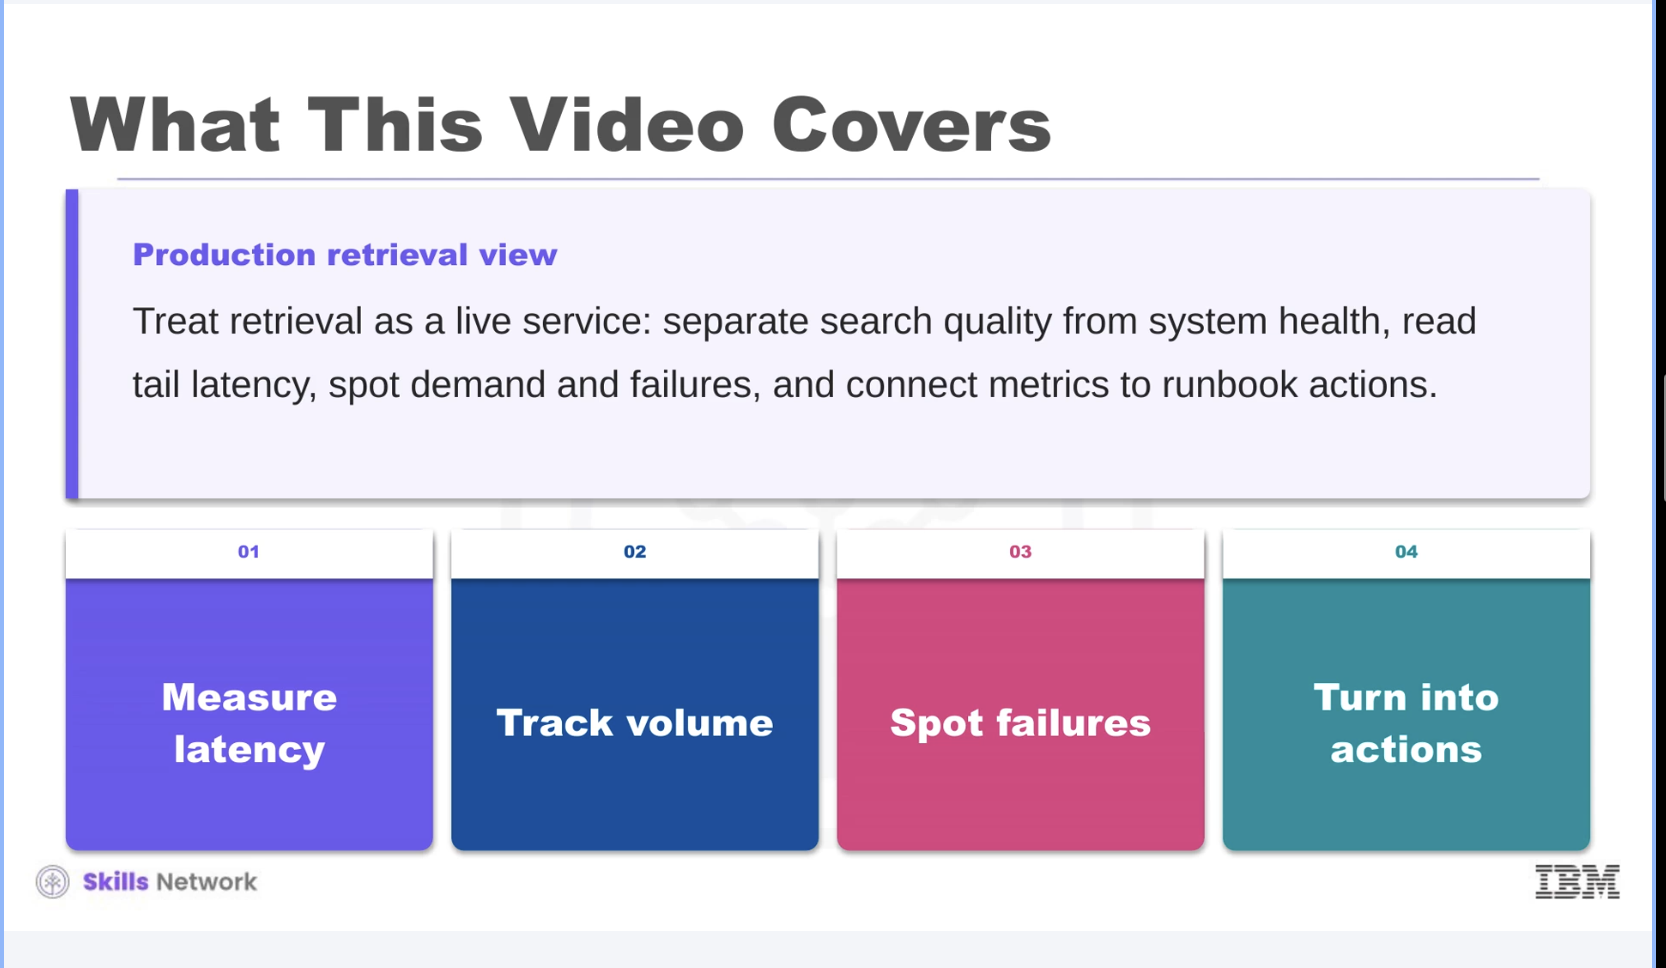
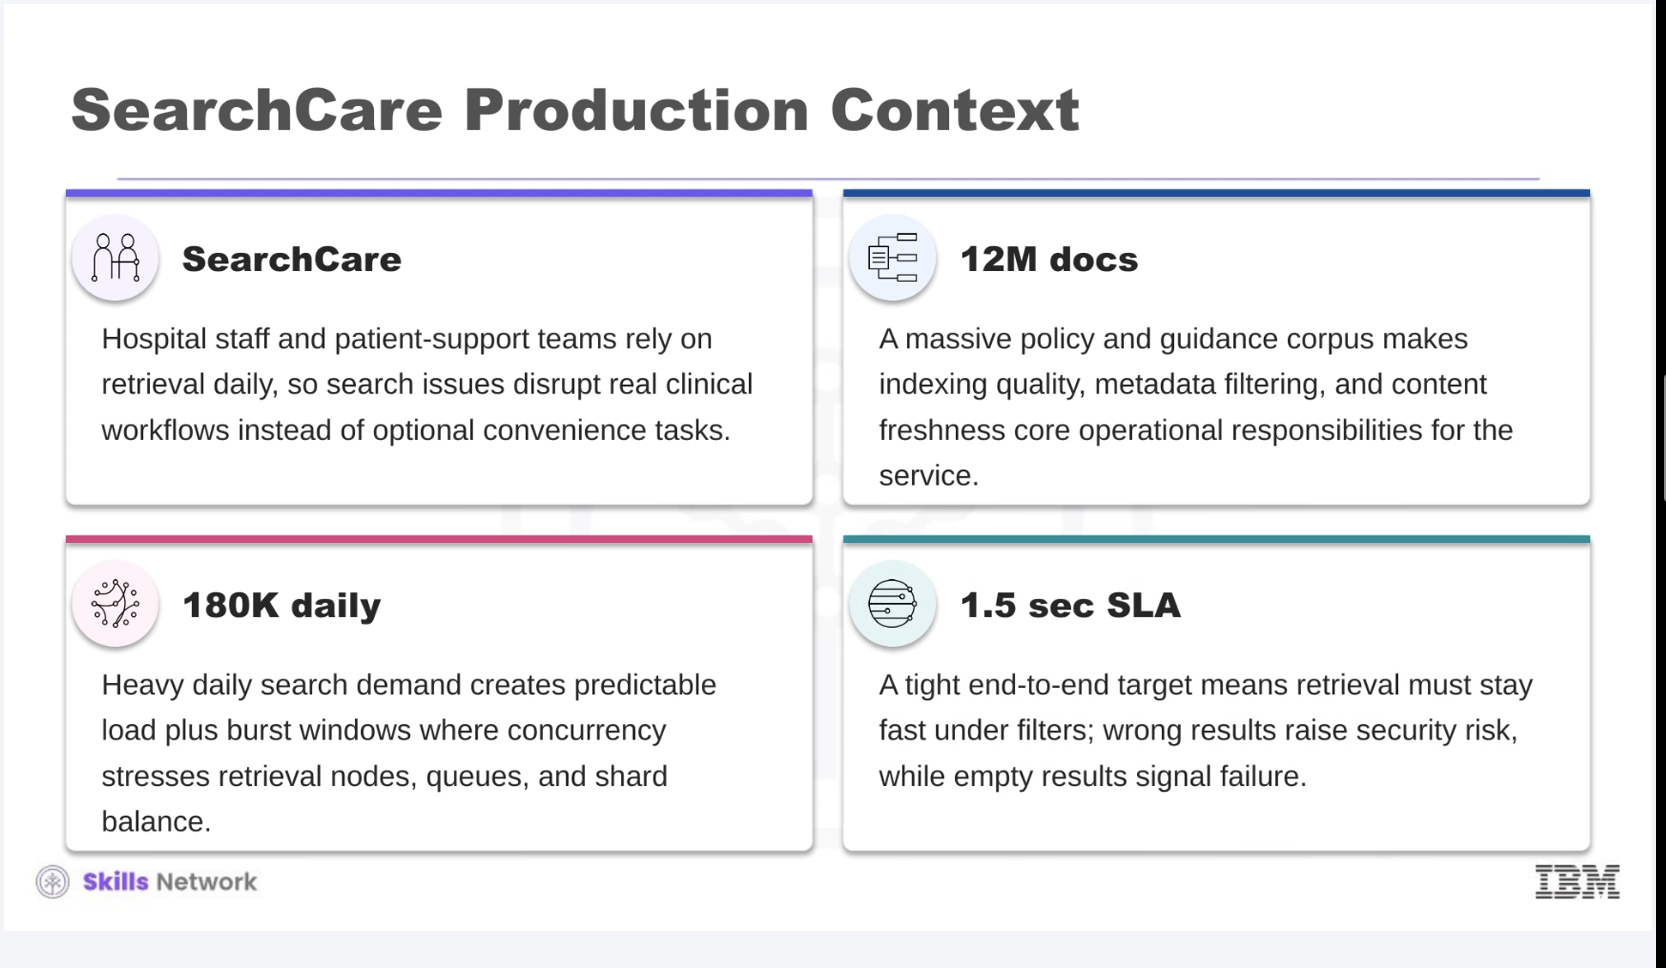
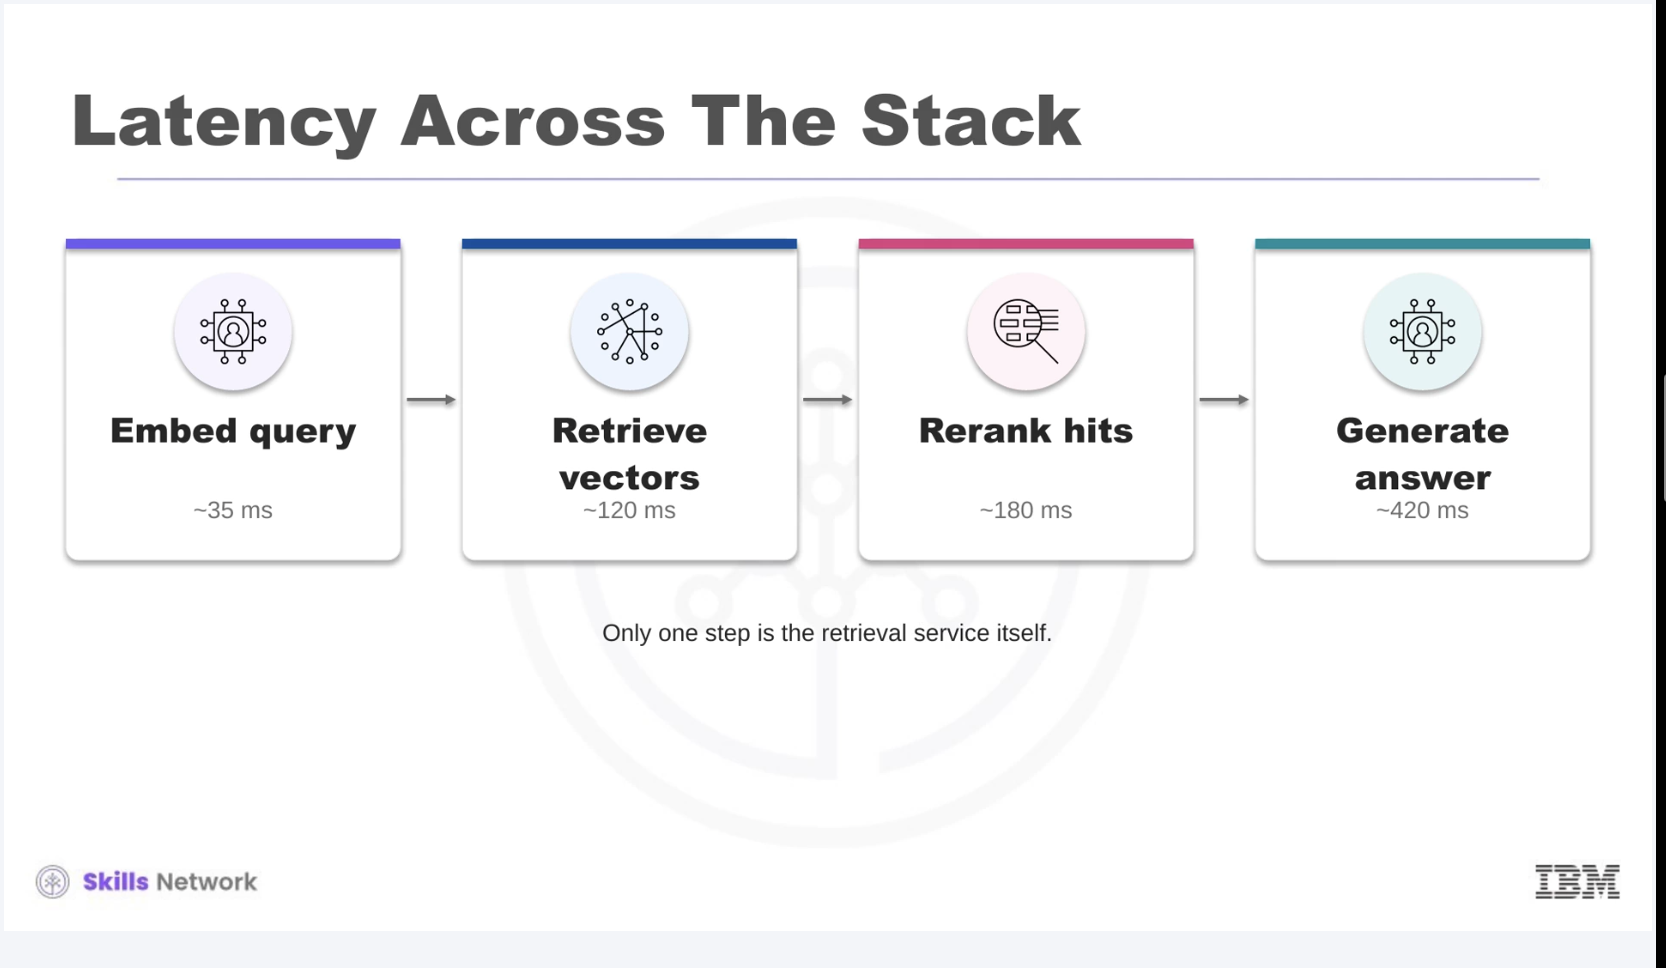
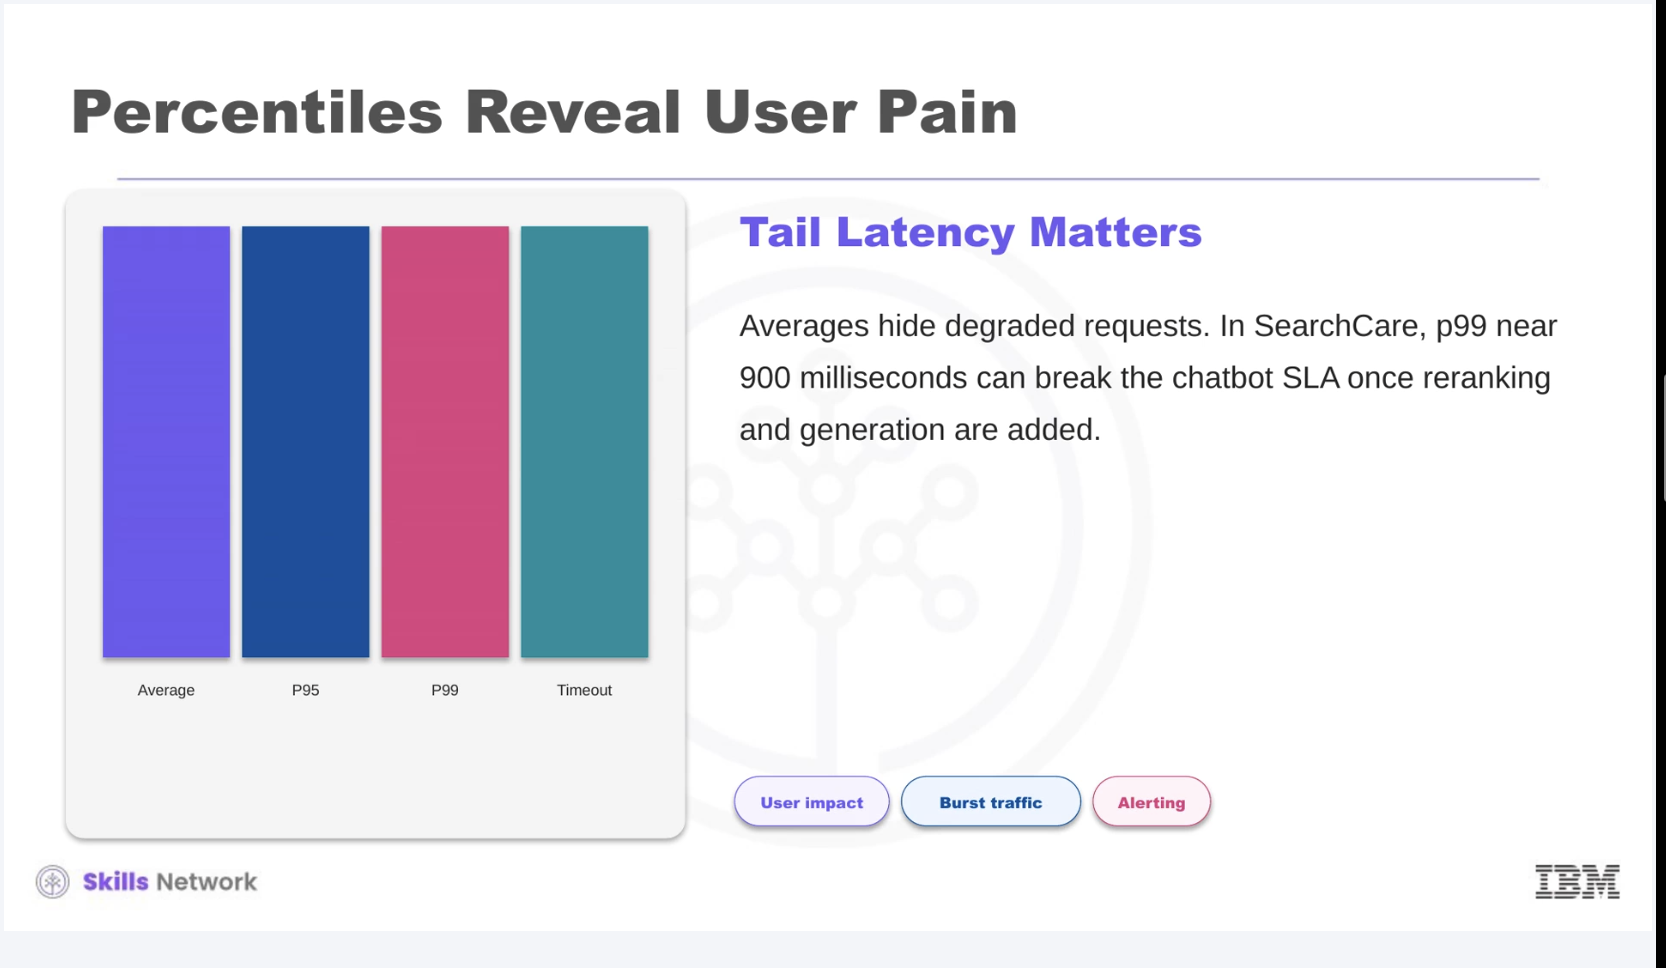
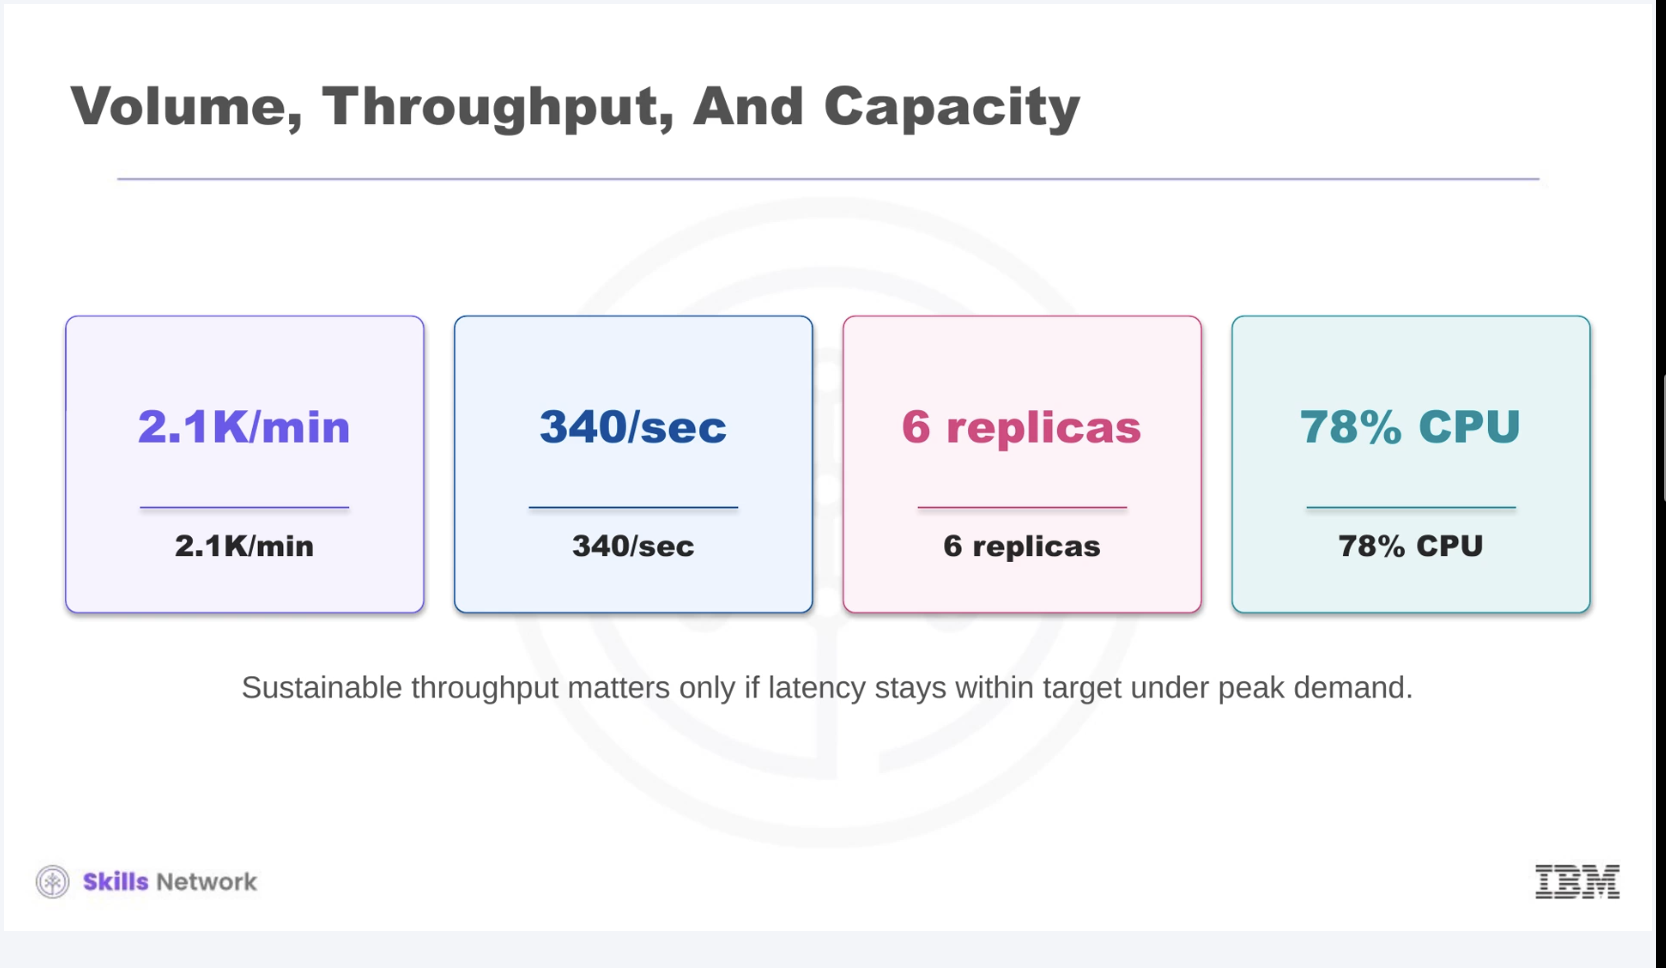
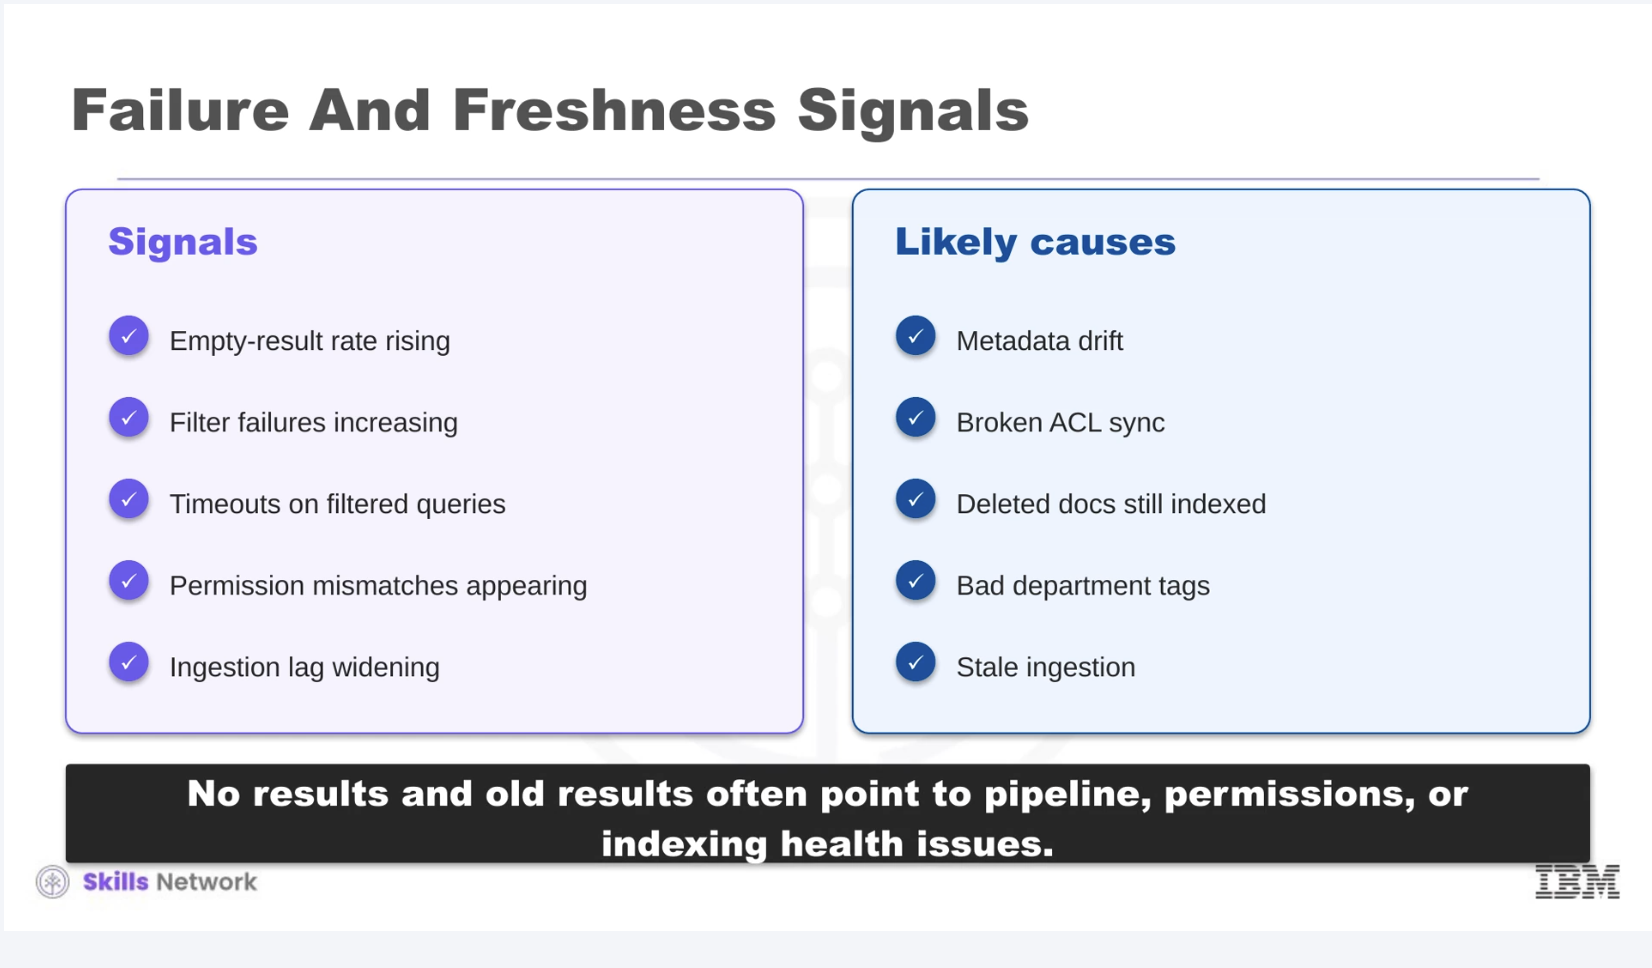
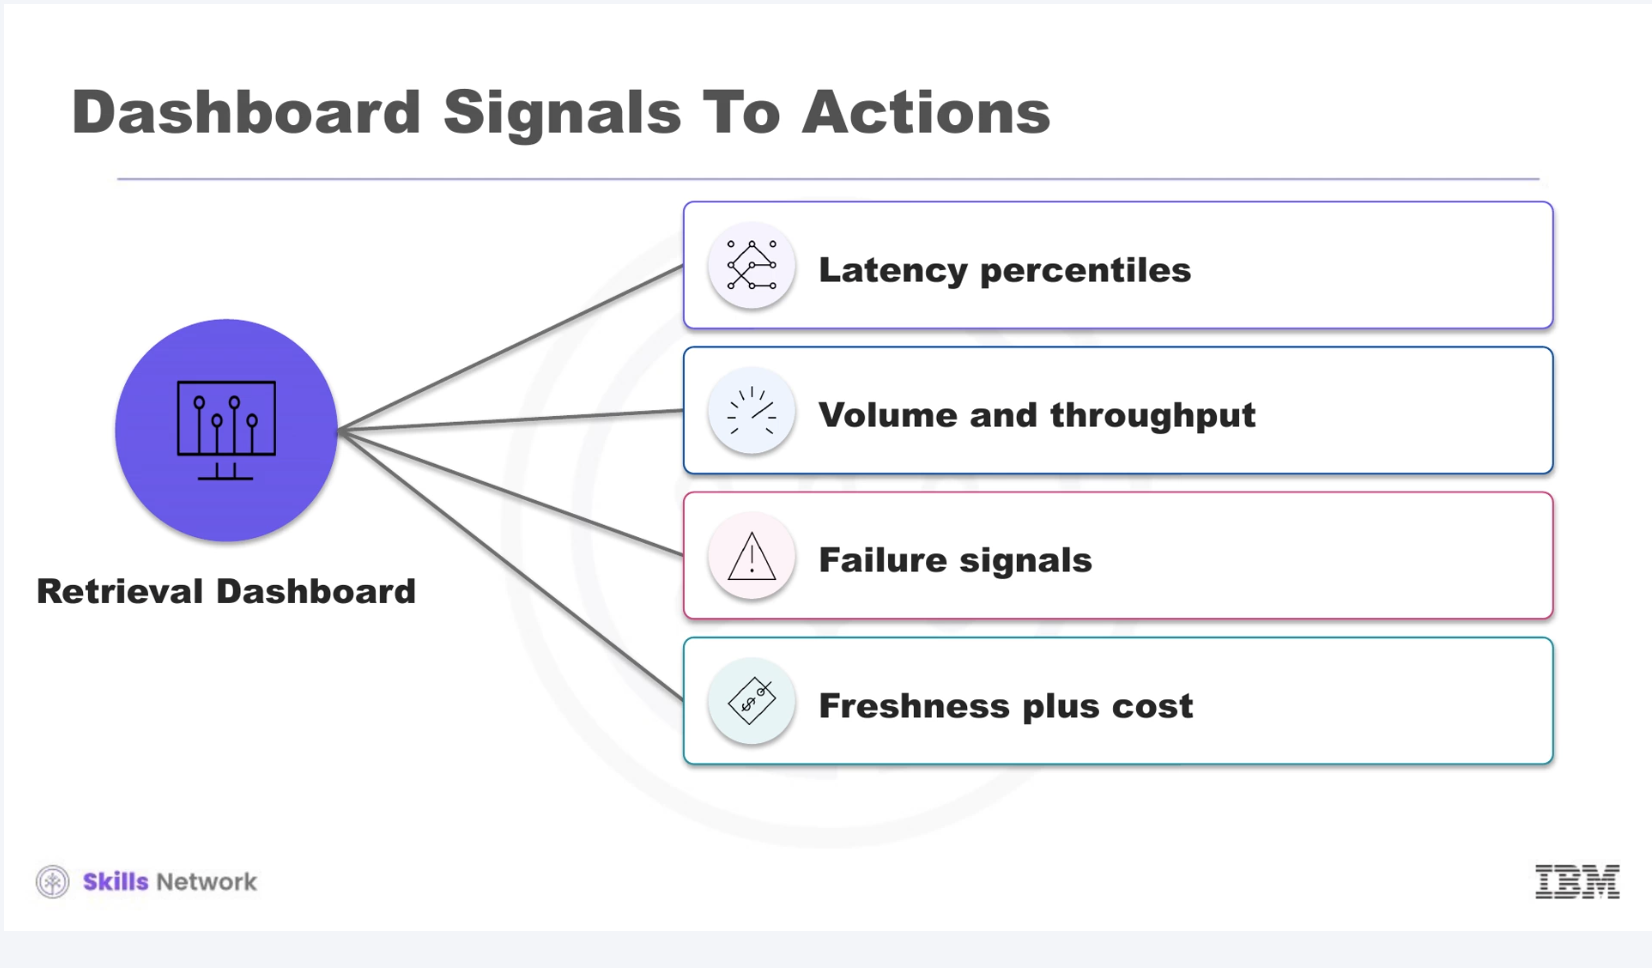


# Retrieval Drift & Retrieval Observability

> 💡 **Core lesson:** Don't monitor whether your RAG system is *alive*. Monitor whether it is still retrieving the **right information** for the **right users** under the **right policies**. That's retrieval observability.

---

## 1. The Problem: Retrieval Drift

First, understand the problem.

Imagine my RAG system is running:

| Component | Status |
|---|---|
| Vector DB | ✅ healthy |
| CPU | ✅ normal |
| Latency | ✅ normal |
| API | ✅ working |

So my monitoring dashboard says:

> "Everything is fine."

But users start saying:

> "Bro, this assistant's answers have become weird."

Maybe it's retrieving:

- old policies
- weaker chunks
- irrelevant documents
- empty results for a particular tenant

**Nothing crashed. The retrieval behavior changed.**

> 💡 That's **retrieval drift**. The course defines it as a change over time in the relationship between the query and returned results that reduces **usefulness, reliability, or policy correctness**.

---

## Why Does Retrieval Drift Happen?

The chapter gives **five major types**.

| # | Drift type | What changed |
|---|---|---|
| 1 | Query distribution drift | The queries themselves |
| 2 | Corpus drift | The data being searched |
| 3 | Embedding drift | The representation (model, preprocessing, chunking) |
| 4 | Relevance decay | Results still semantically relevant but operationally outdated |
| 5 | Metadata distribution drift | Metadata/filtering behavior |

### 1. Query distribution drift

The queries themselves change.

Suppose I originally designed my system around short, simple queries:

```
"What is the refund period?"
"What is our SLA?"
"How do I reset my password?"
```

Later users start asking:

```
"My payment failed after the account was suspended,
what happens to the refund if the transaction was already settled?"
```

Now the query distribution is **completely different**.

> 📌 My infrastructure doesn't care. My **retrieval quality** might.

### 2. Corpus drift

The data I'm searching changes. For example:

- Old documents deleted
- New documents added
- Policies updated
- New data sources introduced
- Stale documents remain

So the vector index is now operating over a **different corpus** than the one it was originally tuned/evaluated against.

### 3. Embedding drift

My representation changes. For example:

```
Embedding model upgrade
       ↓
Different vectors
       ↓
Different nearest neighbors
       ↓
Different retrieval behavior
```

Even **preprocessing or chunking** changes can cause this.

> 📌 The chapter specifically groups **model, preprocessing, and chunking** changes under embedding drift.

This should immediately remind me of the **CareBridge** case:

```
chunker v2.3 → v2.4
12.1 chunks/doc → 13.4
```

and retrieval quality fell.

### 4. Relevance decay

The result can still be **semantically relevant** but **operationally outdated**.

Example — user asks:

> "What is the current cancellation policy?"

Retriever finds:

```
2024 cancellation policy
```

It's semantically relevant. But it's **not the current policy**.

> ⚠️ **Semantic similarity ≠ operational correctness.** That's a huge concept for production RAG.

### 5. Metadata distribution drift

My metadata/filtering behavior changes. For example:

```
department_id
```

gets replaced by:

```
dept_id
```

My vector search might still work perfectly. But my **filters suddenly stop matching** the intended records.

> 📌 The chapter gives exactly this kind of example: **global empty-result rate can look healthy** while one tenant's finance-policy queries jump to **12%** because a metadata filter key changed.

---

## The Mental Model

Think of retrieval drift as:

```
The system still RUNS
        ↓
but the meaning of
"what should be retrieved"
has changed
        ↓
retrieval quality deteriorates
```

The course gives a really good analogy:

> 💡 **Drift is like schema evolution for meaning.**

The pipeline continues running, but what the system considers **comparable** or **eligible** has changed.

That's the core idea.

---

## 2. What Do We Actually Monitor?

Now we move from:

> "Drift exists."

to:

> "How the fuck do we detect it?"

The chapter groups observability into **six signal families**:

| Signal | What we're checking |
|---|---|
| Quality | Are retrieved results still useful? |
| Latency | Is retrieval still fast enough? |
| Throughput | Is workload stressing the system? |
| Freshness | Are results recent enough? |
| Coverage | Are we retrieving from the right corpus? |
| Policy/access | Are permission-aware results behaving correctly? |

### Quality

Things like:

- Empty-result rate
- Recall over time
- Top-result success
- Stale-result share

This answers:

> "Are users still getting useful evidence?"

### Latency

Instead of only saying:

```
retrieval = 200ms
```

I break it down:

- Vector search
- Metadata filtering
- Reranking
- Document fetch

Because suppose:

| Stage | Time |
|---|---|
| Vector search | 100 ms |
| Filter | **500 ms** ← the real problem |
| Reranker | 100 ms |

My total is bad, but **the vector database isn't the problem**.

> ⚠️ The course specifically warns that a **single `retrieval_latency_ms` number** can leave me **debugging the wrong component**.

---

## 3. Why Slicing Is So Damn Important

This is probably the **biggest practical lesson** of this chapter.

Suppose:

```
Global empty-result rate = 1.2%
```

Looks great. But break it down:

| By tenant | Empty-result rate |
|---|---|
| Tenant A | 0.8% |
| Tenant B | 1.1% |
| Tenant C | **12%** ⚠️ |

Now I have a problem. Or:

| By language | Empty-result rate |
|---|---|
| English | 1% |
| Spanish | 2% |
| German | **10%** ⚠️ |

Or:

| By query type | Empty-result rate |
|---|---|
| General queries | 1% |
| Policy queries | 2% |
| Finance-policy | **12%** ⚠️ |

> ⚠️ **The global average hides the failure.**

The chapter says to routinely slice by:

- query category
- corpus segment
- tenant/customer
- time window
- language/region
- permission mode

### Connection to my security architecture

I don't just want:

```
Recall = 0.90
```

I want to know:

| Slice | Recall |
|---|---|
| Public documents | 0.94 |
| Internal documents | 0.91 |
| Restricted documents | **0.72** |
| Tenant A | 0.93 |
| Tenant B | 0.89 |
| Tenant C | **0.61** |

> 📌 A retrieval failure in a **restricted/security-sensitive slice** can be much more important than a small global quality degradation.

---

## 4. Dashboard ≠ Bunch of Graphs

The chapter makes an important distinction.

| ✅ A good dashboard answers | ❌ Not |
|---|---|
| "Something changed. Where should I investigate?" | "Look at my 37 beautiful graphs." 😂 |

It recommends organizing dashboards around:

| Section | Panels |
|---|---|
| **Quality** | Empty result rate<br>Gold-set trends<br>Coverage by category<br>Stale result share |
| **Performance** | p50<br>p95<br>Rerank time<br>Filter time |
| **Freshness** | Indexing lag<br>Source update delay<br>Re-embedding volume |
| **Access control** | Pre-filter result count<br>Post-filter result count<br>Tenant anomalies<br>Policy changes |

---

## 5. The Pre-filter vs Post-filter Diagnostic

This part is **very relevant to my security RAG**.

Suppose:

| Stage | Candidates |
|---|---|
| Before filtering | 100 |
| After policy filtering | **2** |

But normally I expect:

```
100 → 80
```

Something is **suspicious**.

The course says:

> 💡 If **pre-filter candidates remain stable** but **post-filter results suddenly collapse**, investigate **metadata labels, policy updates, or the filter service**, rather than immediately tuning the vector index.

That's a very useful debugging distinction:

| Symptom | Where to investigate |
|---|---|
| Vector search okay → Candidates okay → **Filtering destroys coverage** | Policy / metadata |
| **Vector search itself produces bad candidates** | Index / embeddings / retrieval |

```
Vector search okay
       ↓
Candidates okay
       ↓
Filtering destroys coverage
       ↓
Investigate policy / metadata
```

versus:

```
Vector search itself produces bad candidates
       ↓
Investigate index / embeddings / retrieval
```

---

## 6. Alerting

Now we've detected drift. We **don't want an alert for every tiny fluctuation**.

The chapter says alerts should be based on **three anchors**:

### 1. Historical baseline

What is normal?

| Normal empty-result rate | Current | Verdict |
|---|---|---|
| 1% | 1.2% | Probably nothing |
| 1% | 5% | **Now investigate** |

### 2. Business impact

Ask:

> How bad is this failure?

A 6-hour freshness lag might be **fine for an archive**. It might be **unacceptable for fraud or permissions**.

### 3. Operational risk

Some signals are dangerous because they can **worsen quickly** or **hide larger problems**.

### Alert severity

The chapter gives three levels:

| Level | Meaning | Examples |
|---|---|---|
| 🔴 **Critical** | User-visible or security/policy-sensitive failure | permission anomaly<br>empty-result surge<br>sustained p95 breach |
| 🟡 **Warning** | Early degradation | recall falling for 3 days<br>freshness lag increasing |
| 🔵 **Informational** | Something changed, but it isn't necessarily bad | re-embedding completed<br>new tenant added<br>corpus volume changed |

### The important part: alerts should be slice-aware

Don't just:

```
empty_result_rate > 5%
```

Instead:

```
tenant = finance_eu
query_category = policy_lookup

empty_result_rate > baseline × 3
for 15 minutes

→ CRITICAL
→ retrieval-platform owner
→ permission-filter runbook
```

The chapter gives essentially this exact structure.

So a good alert tells the engineer:

| Question | From the example |
|---|---|
| WHAT happened? | empty-result rate > baseline × 3 |
| WHERE? | tenant `finance_eu`, `policy_lookup` queries |
| HOW BAD? | CRITICAL |
| FOR HOW LONG? | 15 minutes |
| WHO owns it? | retrieval-platform owner |
| WHAT should they do? | permission-filter runbook |

---

## 7. Governance & Auditability

Now this becomes directly relevant to my security project.

Observability isn't only:

> "Is the system fast?"

I may eventually need to answer:

- What changed?
- When did it change?
- Who owned the alert?
- What happened before the degradation?
- What policy changed?
- What embedding/chunking version was running?
- What evaluation proved the system was okay?

So the chapter says my observability package should contain:

- dashboard definitions
- metric formulas
- slice definitions
- alert severity policy
- ownership
- runbooks
- embedding/chunking/index/filter change logs
- evaluation limitations/review cadence

And there's a very important statement:

> ⚠️ **Observability is not omniscience.**

My monitoring itself has **blind spots**. So I need to **document what my evaluation does and doesn't cover**.

---

## The Whole Chapter in One Architecture

This is the mental model to keep:

```
                    RAG SYSTEM
                        │
                        ▼
                  Retrieval Layer
                        │
          ┌─────────────┼─────────────┐
          ▼             ▼             ▼
       Quality       Freshness     Access
          │             │             │
       Recall         Lag         Policy hits
       MRR             Age        Filter rate
       Empty           Updates    Tenant anomalies
       results
          │             │             │
          └─────────────┼─────────────┘
                        ▼
                 Slice the data
                        │
        ┌───────────────┼───────────────┐
        ▼               ▼               ▼
      Tenant         Query type      Language
        │               │               │
        └───────────────┼───────────────┘
                        ▼
                    Alerts
                        │
                        ▼
                    Runbook
                        │
                        ▼
                 Investigation
                        │
                        ▼
                 Fix + Validate
```

And the single most important takeaway:

> 💡 **Don't monitor whether your RAG system is alive. Monitor whether it is still retrieving the right information for the right users under the right policies.**

That's retrieval observability.

---

## What to Actually Remember

| Priority | Topics |
|---|---|
| 🔴 **Must know** | - Retrieval drift<br>- Query/corpus/embedding/relevance/metadata drift<br>- Quality vs infrastructure health<br>- Slice-based monitoring<br>- Freshness + permission monitoring<br>- Pre-filter vs post-filter diagnostics<br>- Baseline + business impact + operational risk for alerts<br>- Alerts need owners + runbooks |
| 🟡 **Understand conceptually** | - Dashboard organization<br>- Instrumentation payload<br>- Alert taxonomy<br>- Governance/audit trail |
| 🟢 **Don't bother memorizing** | - The exact JSON example<br>- Exact alert syntax<br>- Every individual dashboard panel |

> 📌 This chapter is basically teaching how to move from **"I built a RAG system"** to **"I can operate and defend this RAG system in production."**

# [Designing a Retrieval Observability Dashboard](Practical2/observe.ipynb)